In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_sample_submission.csv
/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train.csv


KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np
import os
import pydicom
import cv2


# Load Data 

In [3]:
# Paths
BASE_PATH = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/'
TRAIN_CSV = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train.csv'
TEST_CSV = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_sample_submission.csv'
TRAIN_IMG_PATH = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train'

# Load CSV
train = pd.read_csv(TRAIN_CSV)
sub = pd.read_csv(TEST_CSV)

print("Train shape:", train.shape)
train.tail()
# /kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_sample_submission.csv

Train shape: (4516842, 2)


,ID,Label
4516837,ID_4a85a3a3f_intraparenchymal,0
4516838,ID_4a85a3a3f_intraventricular,0
4516839,ID_4a85a3a3f_subarachnoid,0
4516840,ID_4a85a3a3f_subdural,0
4516841,ID_4a85a3a3f_any,0


In [4]:
train['Label'].value_counts()

Label
0    4260600
1     256242
Name: count, dtype: int64

## STEP 2.1: EXTRACT TYPE + FILENAME

In [5]:
train['type'] = train['ID'].str.split('_').str[2]
train['filename'] = train['ID'].apply(lambda x: "ID_" + x.split('_')[1] + ".dcm")

train.head(7)

,ID,Label,type,filename
0,ID_12cadc6af_epidural,0,epidural,ID_12cadc6af.dcm
1,ID_12cadc6af_intraparenchymal,0,intraparenchymal,ID_12cadc6af.dcm
2,ID_12cadc6af_intraventricular,0,intraventricular,ID_12cadc6af.dcm
3,ID_12cadc6af_subarachnoid,0,subarachnoid,ID_12cadc6af.dcm
4,ID_12cadc6af_subdural,0,subdural,ID_12cadc6af.dcm
5,ID_12cadc6af_any,0,any,ID_12cadc6af.dcm
6,ID_38fd7baa0_epidural,0,epidural,ID_38fd7baa0.dcm


## STEP 2.2 → CREATE MULTI-LABEL (pivot)

In [6]:
pivot_df = train[['Label', 'filename', 'type']].drop_duplicates().pivot(
    index='filename',
    columns='type',
    values='Label'
).reset_index()

pivot_df.head()

type,filename,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,ID_000012eaf.dcm,0,0,0,0,0,0
1,ID_000039fa0.dcm,0,0,0,0,0,0
2,ID_00005679d.dcm,0,0,0,0,0,0
3,ID_00008ce3c.dcm,0,0,0,0,0,0
4,ID_0000950d7.dcm,0,0,0,0,0,0


In [7]:
pivot_df.fillna(0, inplace=True)

In [8]:
pivot_df.isna().sum()

type
filename            0
any                 0
epidural            0
intraparenchymal    0
intraventricular    0
subarachnoid        0
subdural            0
dtype: int64

In [9]:
print(pivot_df.head())
print(pivot_df.shape)

type          filename  any  epidural  intraparenchymal  intraventricular  \
0     ID_000012eaf.dcm    0         0                 0                 0   
1     ID_000039fa0.dcm    0         0                 0                 0   
2     ID_00005679d.dcm    0         0                 0                 0   
3     ID_00008ce3c.dcm    0         0                 0                 0   
4     ID_0000950d7.dcm    0         0                 0                 0   

type  subarachnoid  subdural  
0                0         0  
1                0         0  
2                0         0  
3                0         0  
4                0         0  
(752803, 7)


# Balacing the Data 

In [10]:
label_cols = [
    'any','epidural','intraparenchymal',
    'intraventricular','subarachnoid','subdural'
]

# Create flag
pivot_df['has_hemorrhage'] = pivot_df[label_cols].sum(axis=1)

# Split
pos_df = pivot_df[pivot_df['has_hemorrhage'] > 0]
neg_df = pivot_df[pivot_df['has_hemorrhage'] == 0]

print("Positive:", len(pos_df))
print("Negative:", len(neg_df))

# Balance
n = min(len(pos_df), len(neg_df), 3000)

pos_sample = pos_df.sample(n, replace=True)
neg_sample = neg_df.sample(n, replace=True)

# Combine
pivot_df = pd.concat([pos_sample, neg_sample]).sample(frac=1).reset_index(drop=True)

Positive: 107933
Negative: 644870


# IMAGE PROCESSING 

## Understanding the Raw image 

In [11]:
sample_path = os.path.join(TRAIN_IMG_PATH, pivot_df['filename'].iloc[0])

dcm = pydicom.dcmread(sample_path)
img = dcm.pixel_array

print(img.shape)
print(img.min(), img.max())

(512, 512)
-1024 2828


## Windowing 

In [12]:
def window_image(img, center, width):
    min_val = center - width // 2
    max_val = center + width // 2

    img = np.clip(img, min_val, max_val)
    img = (img - min_val) / (max_val - min_val)

    return img

## Preproccesing Image

In [13]:
def preprocess_image(path):
    try:
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(float)

        brain = window_image(img, 40, 80)
        subdural = window_image(img, 80, 200)
        bone = window_image(img, 600, 2800)

        img = np.stack([brain, subdural, bone], axis=-1)

        img = cv2.resize(img, (299, 299))

        return img

    except:
        return None

In [14]:
img = preprocess_image(sample_path)

if img is not None:
    print("SUCCESS:", img.shape)
else:
    print("FAILED")

SUCCESS: (299, 299, 3)


## DICOM - PNG 

In [15]:
## ----------------------- Folder created ---------------
SAVE_PATH = '/kaggle/working/png_images/'
os.makedirs(SAVE_PATH, exist_ok=True)

In [16]:
def save_as_png(filename):
    dcm_path = os.path.join(TRAIN_IMG_PATH, filename)
    
    img = preprocess_image(dcm_path)
    
    if img is not None:
        img = (img * 255).astype(np.uint8)

        save_path = os.path.join(SAVE_PATH, filename.replace('.dcm', '.png'))
        cv2.imwrite(save_path, img)

In [17]:
from tqdm import tqdm

for fname in tqdm(pivot_df['filename'].head(2000)):
    save_as_png(fname)

100%|██████████| 2000/2000 [01:17<00:00, 25.91it/s]


In [18]:
print(len(os.listdir(SAVE_PATH)))
print(os.listdir(SAVE_PATH)[:5])

1993
['ID_b93ccf9dc.png', 'ID_d125fb772.png', 'ID_cfa6c463d.png', 'ID_5524941c5.png', 'ID_86251a671.png']


In [19]:
label_cols = [
    'any','epidural','intraparenchymal',
    'intraventricular','subarachnoid','subdural'
]

# create flag again (if not present)
pivot_df['has_hemorrhage'] = pivot_df[label_cols].sum(axis=1)

# count
pos_count = (pivot_df['has_hemorrhage'] > 0).sum()
neg_count = (pivot_df['has_hemorrhage'] == 0).sum()

print("Positive (hemorrhage):", pos_count)
print("Negative (normal):", neg_count)

Positive (hemorrhage): 3000
Negative (normal): 3000


In [20]:
print(pivot_df[label_cols].sum())

type
any                 3000
epidural              85
intraparenchymal    1021
intraventricular     784
subarachnoid         972
subdural            1309
dtype: int64


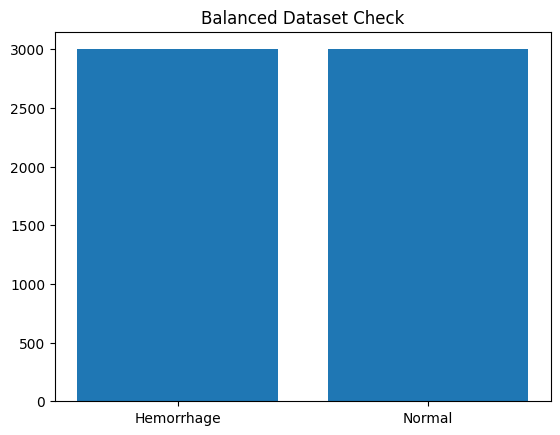

In [21]:
import matplotlib.pyplot as plt

counts = [pos_count, neg_count]
labels = ['Hemorrhage', 'Normal']

plt.bar(labels, counts)
plt.title("Balanced Dataset Check")
plt.show()

# Create Data Generator 

In [27]:
pivot_df['filepath'] = pivot_df['filename'].apply(
    lambda x: os.path.join(SAVE_PATH, x)
)

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 4

datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,

    brightness_range=[0.9, 1.1],

    horizontal_flip=True,
    validation_split=0.25
)

2026-04-16 12:08:37.355288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776341317.533912      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776341317.592371      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776341318.050551      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776341318.050599      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776341318.050602      55 computation_placer.cc:177] computation placer alr

In [28]:
train_gen = datagen.flow_from_dataframe(
    pivot_df,
    directory=SAVE_PATH,
    x_col='filepath',
    y_col=[
        'any','epidural','intraparenchymal',
        'intraventricular','subarachnoid','subdural'
    ],
    class_mode='raw',
    target_size=(299, 299),
    batch_size=BATCH_SIZE,
    subset='training'
)

val_gen = datagen.flow_from_dataframe(
    pivot_df,
    directory=SAVE_PATH,
    x_col='filepath',
    y_col=[
        'any','epidural','intraparenchymal',
        'intraventricular','subarachnoid','subdural'
    ],
    class_mode='raw',
    target_size=(299, 299),
    batch_size=BATCH_SIZE,
    subset='validation'
)

Found 1521 validated image filenames.
Found 506 validated image filenames.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 3973 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 3973 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


In [24]:
# 1. filenames updated
pivot_df['filename'] = pivot_df['filename'].str.replace('.dcm', '.png')

# 2. files exist
os.path.exists(os.path.join(SAVE_PATH, pivot_df['filename'].iloc[0]))

True

# Model 

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [30]:
import keras_tuner as kt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

def build_model(hp):
    
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(299,299,3)
    )

    # 🔥 Tune how many layers to freeze
    freeze_layers = hp.Int('freeze_layers', min_value=50, max_value=200, step=50)

    for layer in base_model.layers[:freeze_layers]:
        layer.trainable = False
    for layer in base_model.layers[freeze_layers:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)

    # 🔥 Tune dense units
    units = hp.Choice('units', [128, 256, 512])
    x = Dense(units, activation='relu')(x)

    # 🔥 Tune dropout
    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    x = Dropout(dropout)(x)

    output = Dense(6, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # 🔥 Tune learning rate
    lr = hp.Choice('learning_rate', [1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [31]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=5,   # keep small on Kaggle
    directory='tuner_results',
    project_name='rsna_tuning'
)

I0000 00:00:1776342318.007971      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776342318.013912      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 05m 46s]
val_auc: 0.7896661758422852

Best val_auc So Far: 0.807884931564331
Total elapsed time: 00h 29m 16s


In [33]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 348 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hp.values)

{'freeze_layers': 50, 'units': 512, 'dropout': 0.30000000000000004, 'learning_rate': 1e-05}


In [35]:
model = tuner.hypermodel.build(best_hp)

In [36]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - auc: 0.6064 - loss: 0.5739
Epoch 1: val_auc improved from -inf to 0.73654, saving model to best_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 153s 243ms/step - auc: 0.6066 - loss: 0.5737 - val_auc: 0.7365 - val_loss: 0.4576 - learning_rate: 1.0000e-05
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - auc: 0.7691 - loss: 0.4183
Epoch 2: val_auc improved from 0.73654 to 0.78449, saving model to best_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 52s 136ms/step - auc: 0.7691 - loss: 0.4183 - val_auc: 0.7845 - val_loss: 0.4095 - learning_rate: 1.0000e-05
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - auc: 0.7932 - loss: 0.4002
Epoch 3: val_auc did not improve from 0.78449
381/381 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - auc: 0.7932 - loss: 0.4002 - val_auc: 0.7839 - val_loss: 0.4064 - learning_rate: 1.0000e-05
Epoch 4/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - auc: 0.8085 - loss: 0.3861
Epoch 4: val_auc improved from 0.78449 to 

In [37]:
model.load_weights('best_model.keras')

# Fine Tune 

In [41]:
# 🔥 Freeze first 50 layers (from tuner result)
for layer in model.layers[:50]:
    layer.trainable = False

# 🔥 Unfreeze remaining layers
for layer in model.layers[50:]:
    layer.trainable = True

# 🔥 Compile (use tuned LR)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

# 🔥 Train
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 151s 241ms/step - auc: 0.8301 - loss: 0.3725 - val_auc: 0.8237 - val_loss: 0.3764 - learning_rate: 1.0000e-05
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - auc: 0.8373 - loss: 0.3684 - val_auc: 0.8258 - val_loss: 0.3782 - learning_rate: 1.0000e-05
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 50s 132ms/step - auc: 0.8395 - loss: 0.3581 - val_auc: 0.8292 - val_loss: 0.3738 - learning_rate: 1.0000e-05
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - auc: 0.8431 - loss: 0.3713 - val_auc: 0.8333 - val_loss: 0.3680 - learning_rate: 1.0000e-05
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - auc: 0.8405 - loss: 0.3635 - val_auc: 0.8282 - val_loss: 0.3748 - learning_rate: 1.0000e-05
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - auc: 0.8447 - loss: 0.3590
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
381/381 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - auc: 0.8447 - loss: 0.3590 - val_auc: 0.8330 - va

In [43]:
model.save("final.keras")

# Accuracy 

In [64]:
preds = model.predict(val_gen)
y_true = val_gen.labels

127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step


In [66]:
y_pred = (preds > 0.5).astype(int)

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=[
    'any','epidural','intraparenchymal',
    'intraventricular','subarachnoid','subdural'
]))

                  precision    recall  f1-score   support

             any       0.52      0.57      0.55       255
        epidural       0.00      0.00      0.00         9
intraparenchymal       1.00      0.01      0.03        75
intraventricular       0.27      0.06      0.09        72
    subarachnoid       0.00      0.00      0.00        77
        subdural       0.24      0.05      0.09       111

       micro avg       0.49      0.26      0.34       599
       macro avg       0.34      0.12      0.13       599
    weighted avg       0.42      0.26      0.26       599
     samples avg       0.28      0.14      0.18       599



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## CONFUSION METRICS

In [68]:
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(y_true, y_pred)

for i, matrix in enumerate(cm):
    print(f"\nClass {i} Confusion Matrix:\n", matrix)


Class 0 Confusion Matrix:
 [[118 133]
 [109 146]]

Class 1 Confusion Matrix:
 [[497   0]
 [  9   0]]

Class 2 Confusion Matrix:
 [[431   0]
 [ 74   1]]

Class 3 Confusion Matrix:
 [[423  11]
 [ 68   4]]

Class 4 Confusion Matrix:
 [[429   0]
 [ 77   0]]

Class 5 Confusion Matrix:
 [[376  19]
 [105   6]]


## ROC_AUC_SCORE

In [69]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_true, preds, average='macro')
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.5195121161737689


## CHARTS 

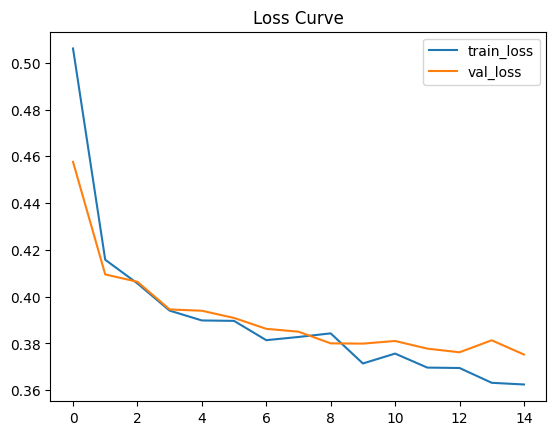

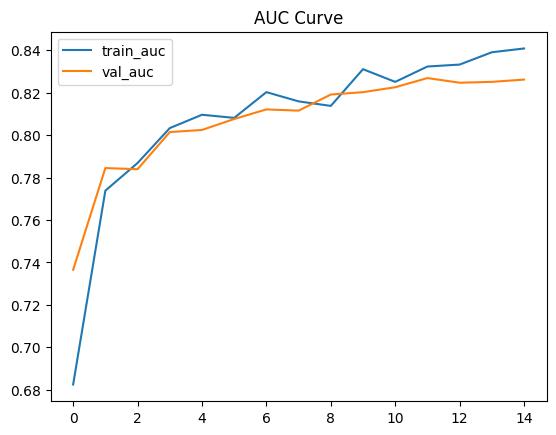

In [72]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

# AUC
plt.plot(history.history['auc'], label='train_auc')
plt.plot(history.history['val_auc'], label='val_auc')
plt.legend()
plt.title("AUC Curve")
plt.show()

## roc_curve per class 

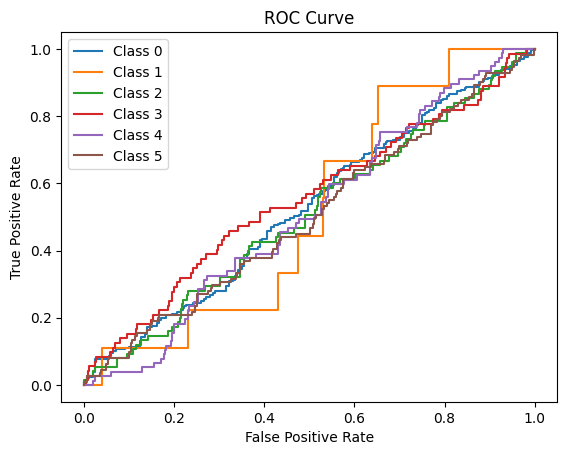

In [73]:
from sklearn.metrics import roc_curve

for i in range(6):
    fpr, tpr, _ = roc_curve(y_true[:, i], preds[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Predictions

In [52]:
import pandas as pd

labels = [
    'any','epidural','intraparenchymal',
    'intraventricular','subarachnoid','subdural'
]

df = pd.DataFrame(preds, columns=[f'pred_{l}' for l in labels])

# actual labels
true_df = pd.DataFrame(y_true, columns=labels)

final_df = pd.concat([true_df, df], axis=1)

In [53]:
for l in labels:
    final_df[f'pred_{l}_bin'] = (final_df[f'pred_{l}'] > 0.5).astype(int)

In [54]:
for l in labels:
    acc = (final_df[l] == final_df[f'pred_{l}_bin']).mean()
    print(f"{l} accuracy:", acc)

any accuracy: 0.5059288537549407
epidural accuracy: 0.9822134387351779
intraparenchymal accuracy: 0.849802371541502
intraventricular accuracy: 0.8399209486166008
subarachnoid accuracy: 0.8478260869565217
subdural accuracy: 0.7569169960474308


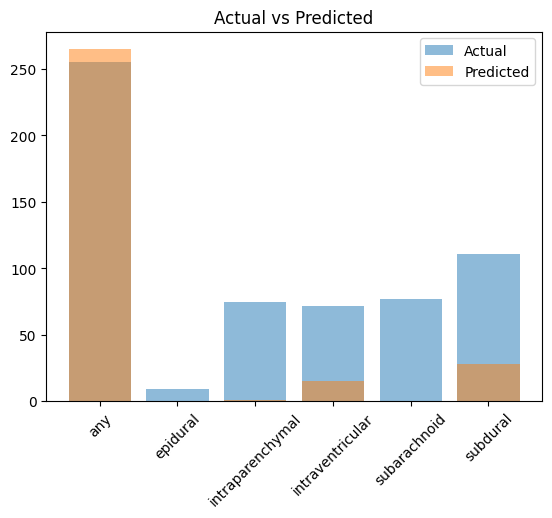

In [55]:
import matplotlib.pyplot as plt

actual = final_df[labels].sum()
predicted = final_df[[f'pred_{l}_bin' for l in labels]].sum()

plt.bar(labels, actual, alpha=0.5, label='Actual')
plt.bar(labels, predicted, alpha=0.5, label='Predicted')

plt.xticks(rotation=45)
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

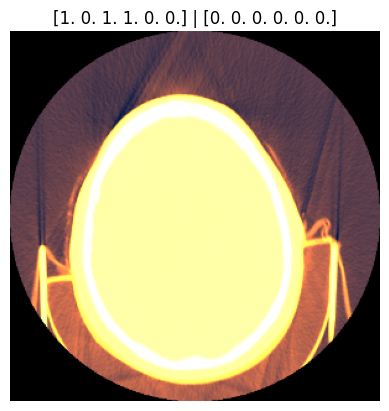

In [56]:
import cv2

img = cv2.imread(val_gen.filepaths[0])

plt.imshow(img)
plt.title(str(final_df.iloc[0][labels].values) + " | " +
          str(final_df.iloc[0][[f'pred_{l}_bin' for l in labels]].values))
plt.axis('off')
plt.show()

In [75]:
positive_cases = pivot_df[pivot_df['any'] == 1]

print("Total positive:", len(positive_cases))

sample = positive_cases.sample(1)
print(sample)

Total positive: 3000
type          filename  any  epidural  intraparenchymal  intraventricular  \
478   ID_3cdf5f864.png    1         0                 1                 1   

type  subarachnoid  subdural  has_hemorrhage  \
478              1         0               4   

type                                     filepath  
478   /kaggle/working/png_images/ID_3cdf5f864.png  


In [76]:
samples = positive_cases.sample(5)

file_list = samples['filename'].tolist()
print(file_list)

['ID_74b7c7c48.png', 'ID_ccac2ac05.png', 'ID_50f300be6.png', 'ID_b7de26273.png', 'ID_959df866a.png']


In [79]:
import os
import shutil

SAVE_DCM_PATH = "/kaggle/working/positive_dcm"
os.makedirs(SAVE_DCM_PATH, exist_ok=True)

In [82]:
TRAIN_IMG_PATH = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train"

for file in file_list:
    
    # 🔹 Convert to DICOM name
    dcm_file = file.replace('.png', '.dcm')
    
    # 🔹 Get image ID
    image_id = file.replace('.png', '').replace('ID_', '')
    
    # 🔹 Get row from pivot_df
    row = pivot_df[pivot_df['filename'] == file]
    
    if row.empty:
        print(f"❌ Not found in pivot_df: {file}")
        continue
    
    row = row.iloc[0]
    
    # 🔥 PRINT HEMORRHAGE TYPES
    print(f"\n🧠 {file}")
    
    ich_types = []
    
    for col in ['epidural','intraparenchymal','intraventricular','subarachnoid','subdural']:
        if row[col] == 1:
            ich_types.append(col)
    
    if len(ich_types) == 0:
        print("✅ No hemorrhage")
    else:
        print("🔴 Hemorrhage types:", ich_types)
    
    # 🔹 Copy DICOM
    src = os.path.join(TRAIN_IMG_PATH, dcm_file)
    dst = os.path.join(SAVE_DCM_PATH, dcm_file)
    
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print("❌ Missing file:", dcm_file)


🧠 ID_74b7c7c48.png
🔴 Hemorrhage types: ['intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

🧠 ID_ccac2ac05.png
🔴 Hemorrhage types: ['intraparenchymal']

🧠 ID_50f300be6.png
🔴 Hemorrhage types: ['subdural']

🧠 ID_b7de26273.png
🔴 Hemorrhage types: ['intraventricular']

🧠 ID_959df866a.png
🔴 Hemorrhage types: ['subarachnoid']


In [85]:
import zipfile
import os

folder_path = "/kaggle/working/positive_dcm"
zip_path = "/kaggle/working/positive_dcm.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in os.listdir("/kaggle/working/png_images"):
        file_path = os.path.join(folder_path, file)
        zipf.write(file_path, file)

print("ZIP created:", zip_path)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/positive_dcm/ID_b93ccf9dc.png'